In [ ]:
## Assignment 3 -Visualization-Leen Magarbeh
## Dataset source: https://data.ontario.ca/dataset/2021-22-schools-with-recent-covid-19-cases
## first visualization: "Total confirmed COVID-19 cases reported in Ontario schools (daily)"
## second visualization: "Top 10 school boards by total confirmed school COVID-19 cases (Sep–Dec 2021)"

In [2]:
## Loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import PIL
import requests

In [3]:
## Loading Data
path = "/Users/leenmagarbeh/Desktop/visualization/02_activities/assignments/COVID_schools.csv"
df = pd.read_csv(path)
df.head()

,_id,collected_date,reported_date,school_board,school_id,school,municipality,confirmed_student_cases,confirmed_staff_cases,confirmed_unspecified_cases,total_confirmed_cases
0,1,2021-09-13T00:00:00,2021-09-14T00:00:00,Avon Maitland District School Board,507725,Shakespeare Public School,Stratford,2,0,0,2
1,2,2021-09-13T00:00:00,2021-09-14T00:00:00,Bruce-Grey Catholic District School Board,732800,St Teresa of Calcutta Catholic School,Brockton,1,0,0,1
2,3,2021-09-13T00:00:00,2021-09-14T00:00:00,Catholic District School Board of Eastern Ontario,691127,J L Jordan Separate School,Brockville,0,1,0,1
3,4,2021-09-13T00:00:00,2021-09-14T00:00:00,Catholic District School Board of Eastern Ontario,758787,Sacred Heart of Jesus Separate School,Lanark Highlands,0,1,0,1
4,5,2021-09-13T00:00:00,2021-09-14T00:00:00,Catholic District School Board of Eastern Ontario,769312,St Andrew's Separate School,South Stormont,2,0,0,2


In [3]:
## First Visualization

### Cleaning data

df["reported_date"] = pd.to_datetime(df["reported_date"], errors="coerce") #converting date column

# 3) Keep only rows with a valid date 
df = df.dropna(subset=["reported_date"])

df.info() ## making sure date was converted correctly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50299 entries, 0 to 50298
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   _id                          50299 non-null  int64         
 1   collected_date               50299 non-null  object        
 2   reported_date                50299 non-null  datetime64[ns]
 3   school_board                 50299 non-null  object        
 4   school_id                    50299 non-null  object        
 5   school                       50299 non-null  object        
 6   municipality                 50299 non-null  object        
 7   confirmed_student_cases      50299 non-null  int64         
 8   confirmed_staff_cases        50299 non-null  int64         
 9   confirmed_unspecified_cases  50299 non-null  int64         
 10  total_confirmed_cases        50299 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(5)

In [4]:

# 4) Aggregate by day (total cases)

df["date"] = df["reported_date"].dt.date

daily = (
    df.groupby("date", as_index=False)["total_confirmed_cases"]
      .sum()
)


daily.head()


,date,total_confirmed_cases
0,2021-09-14,324
1,2021-09-15,476
2,2021-09-16,557
3,2021-09-17,618
4,2021-09-20,716


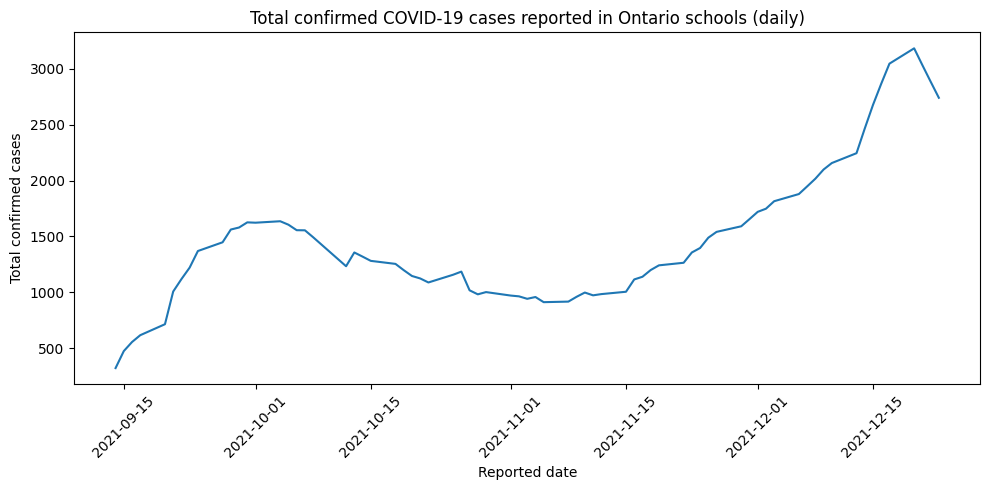

In [5]:
# 5) Plot
plt.figure(figsize=(10, 5))
plt.plot(daily["date"], daily["total_confirmed_cases"])
plt.title("Total confirmed COVID-19 cases reported in Ontario schools (daily)")
plt.xlabel("Reported date")
plt.ylabel("Total confirmed cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
### Second Visualization
### cleaning data
df["school_board"] = df["school_board"].astype(str).str.strip()
### conversts school board to string

In [7]:
board = (
    df.groupby("school_board", as_index=False)["total_confirmed_cases"]
      .sum()
      .sort_values("total_confirmed_cases", ascending=False)
      .head(10)
)

## groups cases by school board 
##sums cases for each school board
##sorts results from highest to lowest 
## keeps the top 10 

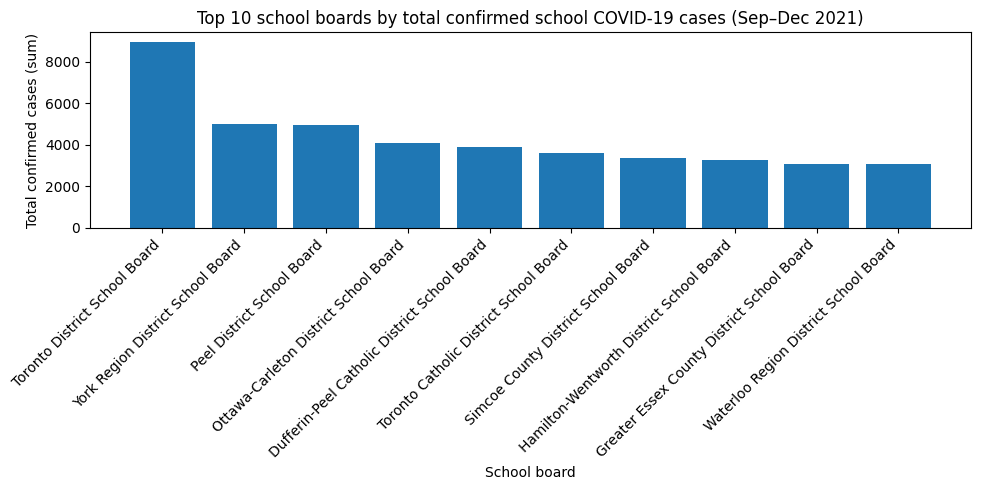

In [8]:
## Plotting

plt.figure(figsize=(10, 5))
plt.bar(board["school_board"], board["total_confirmed_cases"])
plt.title("Top 10 school boards by total confirmed school COVID-19 cases (Sep–Dec 2021)")
plt.xlabel("School board")
plt.ylabel("Total confirmed cases (sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
### another graph in excel 
### exporting data to excel file
municipality = (
    df.groupby("municipality", as_index=False)["total_confirmed_cases"]
      .sum()
      .sort_values("total_confirmed_cases", ascending=False)
      .head(10)
)

municipality.to_csv("top_municipalities_covid_schools.csv", index=False)

